# Human Activity Recognition — UCI HAR Dataset

**Classify 6 daily activities from smartphone accelerometer + gyroscope data**

| | |
|---|---|
| **Dataset** | UCI HAR — 30 subjects, Samsung Galaxy S II |
| **Samples** | 7,352 train · 2,947 test |
| **Features** | 561 (time + frequency domain, pre-extracted) |
| **Classes** | WALKING · WALKING_UPSTAIRS · WALKING_DOWNSTAIRS · SITTING · STANDING · LAYING |
| **Signals** | 3-axial accel + 3-axial gyro at 50 Hz, 2.56 s windows with 50% overlap |

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

COLORS = ['#4f46e5','#7c3aed','#db2777','#ea580c','#059669','#0891b2']
ACTIVITIES = ['WALKING','WALKING_UPSTAIRS','WALKING_DOWNSTAIRS',
              'SITTING','STANDING','LAYING']
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [2]:
BASE = 'UCI HAR Dataset/'

def load_dataset():
    X_train = pd.read_csv(BASE+'train/X_train.txt', sep=r'\s+', header=None)
    X_test  = pd.read_csv(BASE+'test/X_test.txt',  sep=r'\s+', header=None)
    y_train = pd.read_csv(BASE+'train/y_train.txt', header=None).squeeze()
    y_test  = pd.read_csv(BASE+'test/y_test.txt',  header=None).squeeze()
    subj_tr = pd.read_csv(BASE+'train/subject_train.txt', header=None).squeeze()
    subj_te = pd.read_csv(BASE+'test/subject_test.txt',   header=None).squeeze()

    raw_feats = pd.read_csv(BASE+'features.txt', sep=r'\s+', header=None)[1].tolist()
    seen, feats = {}, []
    for f in raw_feats:
        if f in seen: seen[f]+=1; feats.append(f"{f}_{seen[f]}")
        else: seen[f]=0; feats.append(f)

    X_train.columns = X_test.columns = feats

    labels = {1:'WALKING', 2:'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS',
              4:'SITTING', 5:'STANDING', 6:'LAYING'}
    return X_train, X_test, y_train, y_test, subj_tr, subj_te, feats, labels

X_train, X_test, y_train, y_test, subj_train, subj_test, features, labels = load_dataset()

print(f"Training set : {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} samples × {X_test.shape[1]} features")
print(f"Subjects     : {subj_train.nunique()} train, {subj_test.nunique()} test")
print(f"Activities   : {list(labels.values())}")

Training set : 7,352 samples × 561 features
Test set     : 2,947 samples × 561 features
Subjects     : 21 train, 9 test
Activities   : ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


## 2. Exploratory Data Analysis

### 2.1 Class Distribution

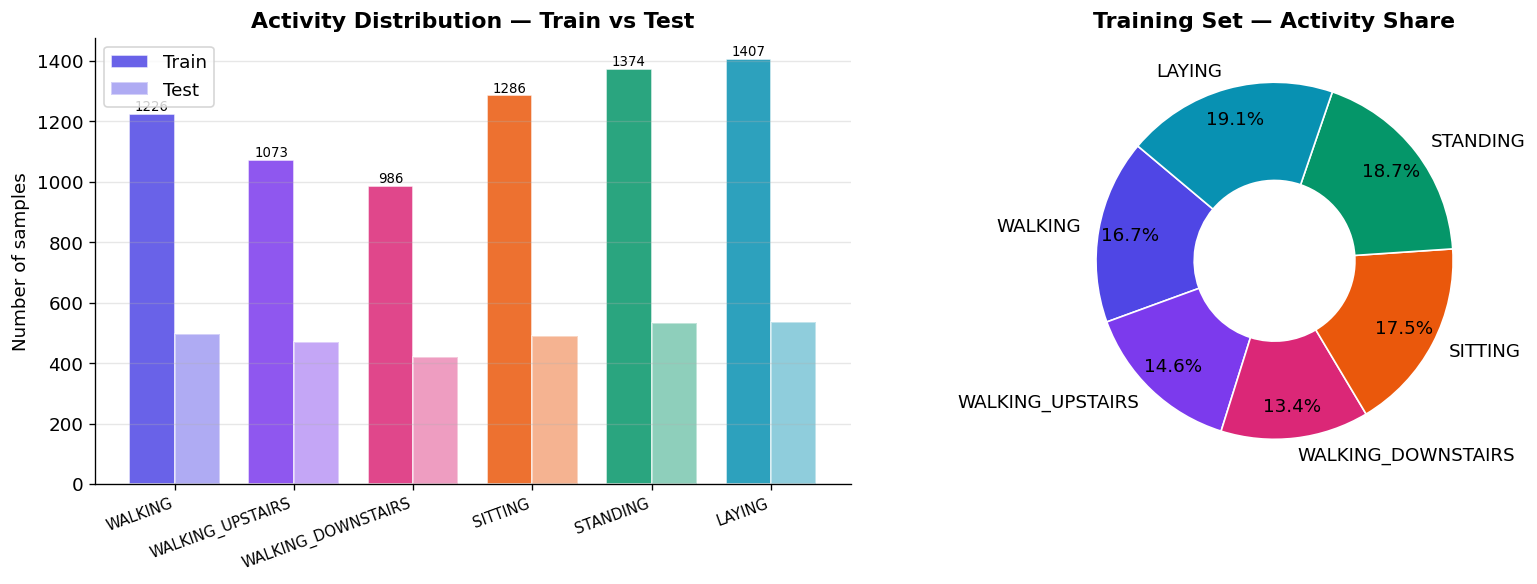

Dataset is well-balanced — no class imbalance issue.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per activity
counts_tr = [( y_train==k).sum() for k in range(1,7)]
counts_te = [( y_test ==k).sum() for k in range(1,7)]

ax = axes[0]
x = np.arange(6); w = 0.38
bars1 = ax.bar(x-w/2, counts_tr, w, label='Train', color=COLORS, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x+w/2, counts_te, w, label='Test',  color=COLORS, alpha=0.45, edgecolor='white', linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels(ACTIVITIES, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Number of samples'); ax.set_title('Activity Distribution — Train vs Test', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+10, str(b.get_height()), ha='center', fontsize=8)

# Pie chart
ax2 = axes[1]
ax2.pie(counts_tr, labels=ACTIVITIES, colors=COLORS, autopct='%1.1f%%',
        startangle=140, pctdistance=0.82, wedgeprops=dict(width=0.55, edgecolor='white'))
ax2.set_title('Training Set — Activity Share', fontweight='bold')

plt.tight_layout(); plt.savefig('plots/class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dataset is well-balanced — no class imbalance issue.")

### 2.2 Per-Subject Activity Count

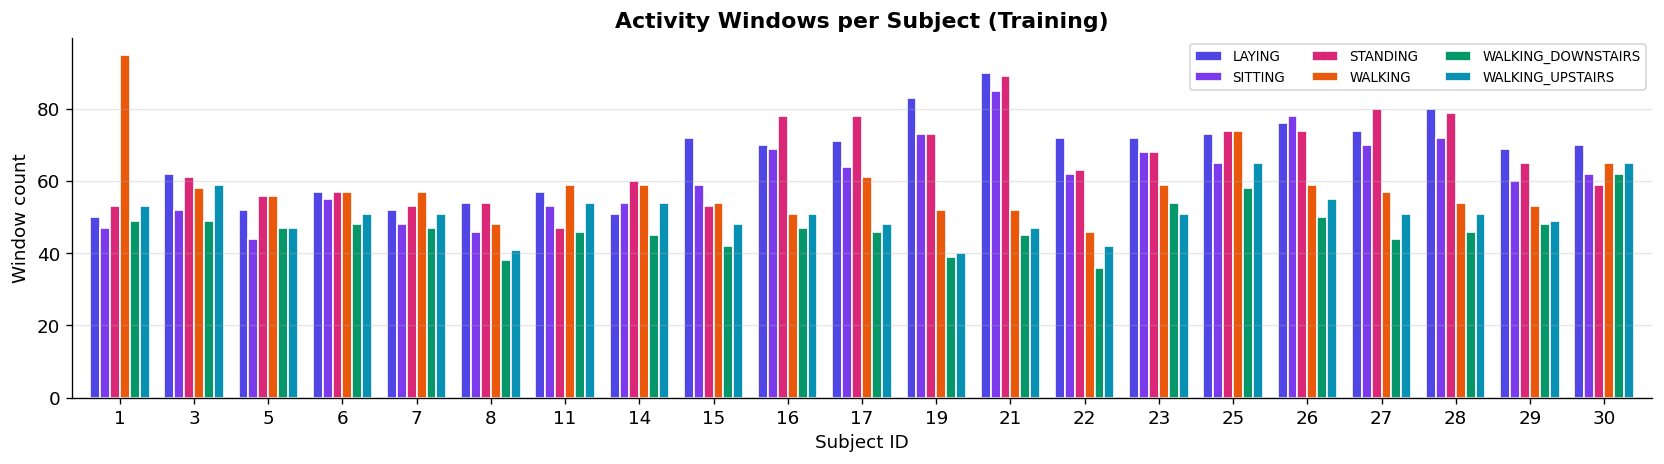

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
subj_act = pd.DataFrame({'subject': subj_train, 'activity': y_train.map(labels)})
pivot = subj_act.groupby(['subject','activity']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=ax, color=COLORS, width=0.8, edgecolor='white')
ax.set_xlabel('Subject ID'); ax.set_ylabel('Window count')
ax.set_title('Activity Windows per Subject (Training)', fontweight='bold')
ax.legend(loc='upper right', ncol=3, fontsize=8)
ax.tick_params(axis='x', rotation=0); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('plots/subject_activity_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.3 PCA — 2D Projection

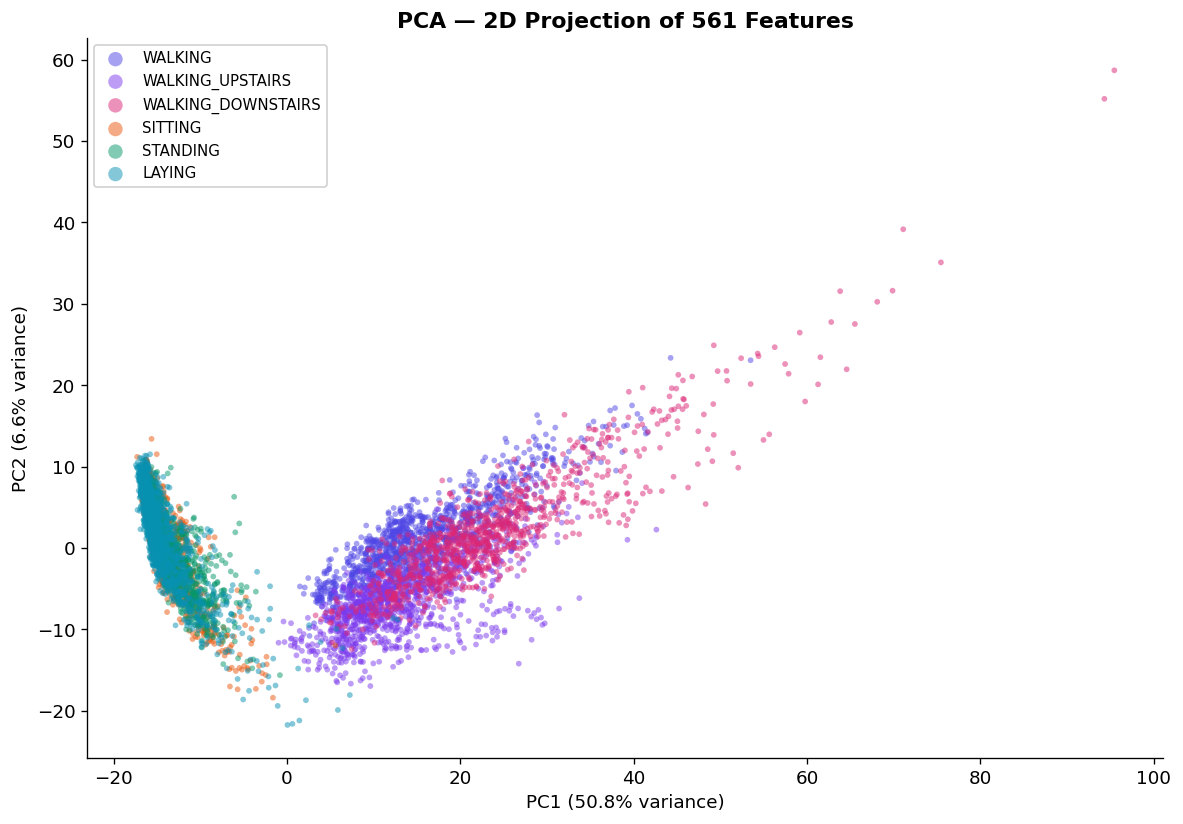

Total variance explained by PC1+PC2: 57.4%


In [5]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tr_sc)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (k, act) in enumerate(labels.items()):
    mask = (y_train == k)
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=COLORS[i], label=act,
               alpha=0.5, s=12, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — 2D Projection of 561 Features', fontweight='bold')
ax.legend(markerscale=2.5, fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.savefig('plots/pca_visualization.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Total variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

### 2.4 t-SNE — 2D Embedding

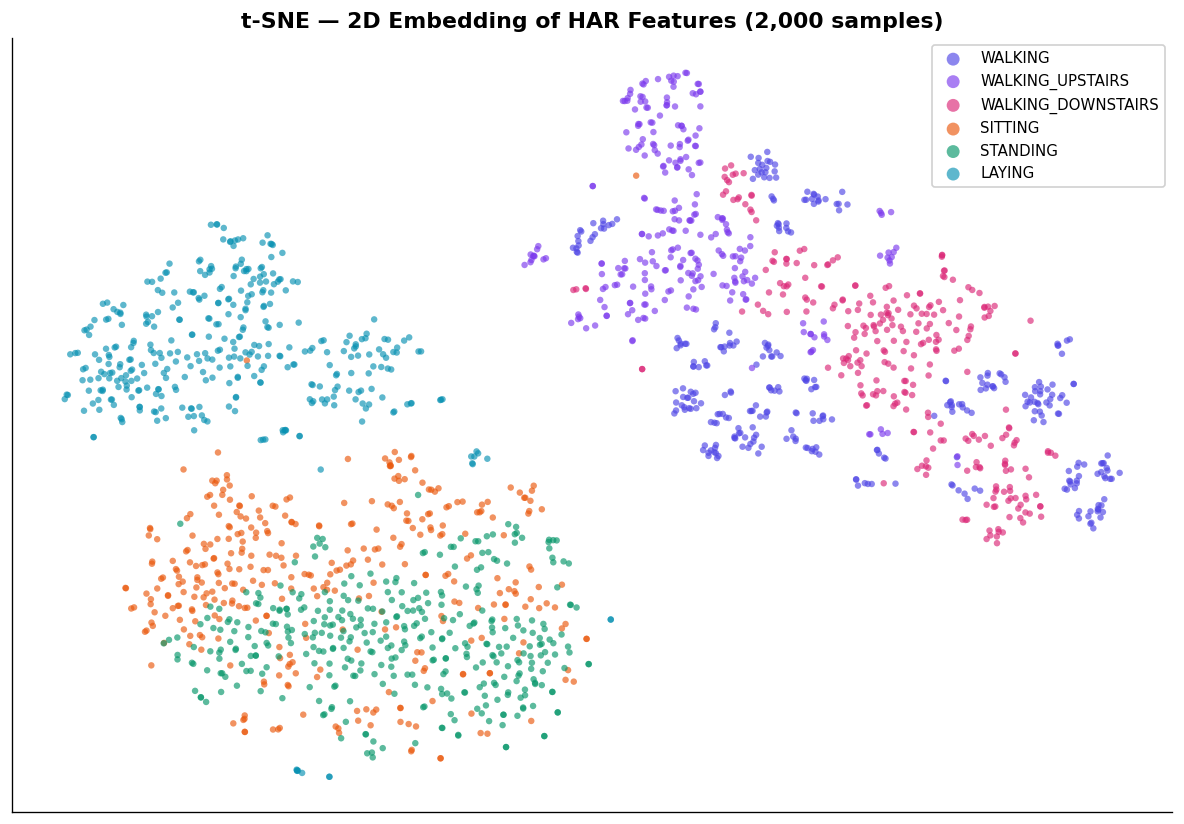

In [6]:
from sklearn.manifold import TSNE
# Use subset for speed
np.random.seed(42)
idx = np.random.choice(len(X_tr_sc), 2000, replace=False)
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_tr_sc[idx])
y_sub  = y_train.values[idx]

fig, ax = plt.subplots(figsize=(10, 7))
for i, (k, act) in enumerate(labels.items()):
    mask = (y_sub == k)
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], c=COLORS[i], label=act,
               alpha=0.65, s=15, edgecolors='none')
ax.set_title('t-SNE — 2D Embedding of HAR Features (2,000 samples)', fontweight='bold')
ax.legend(markerscale=2, fontsize=9, framealpha=0.9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig('plots/tsne_visualization.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.5 Raw Signal Plots — Body Acceleration

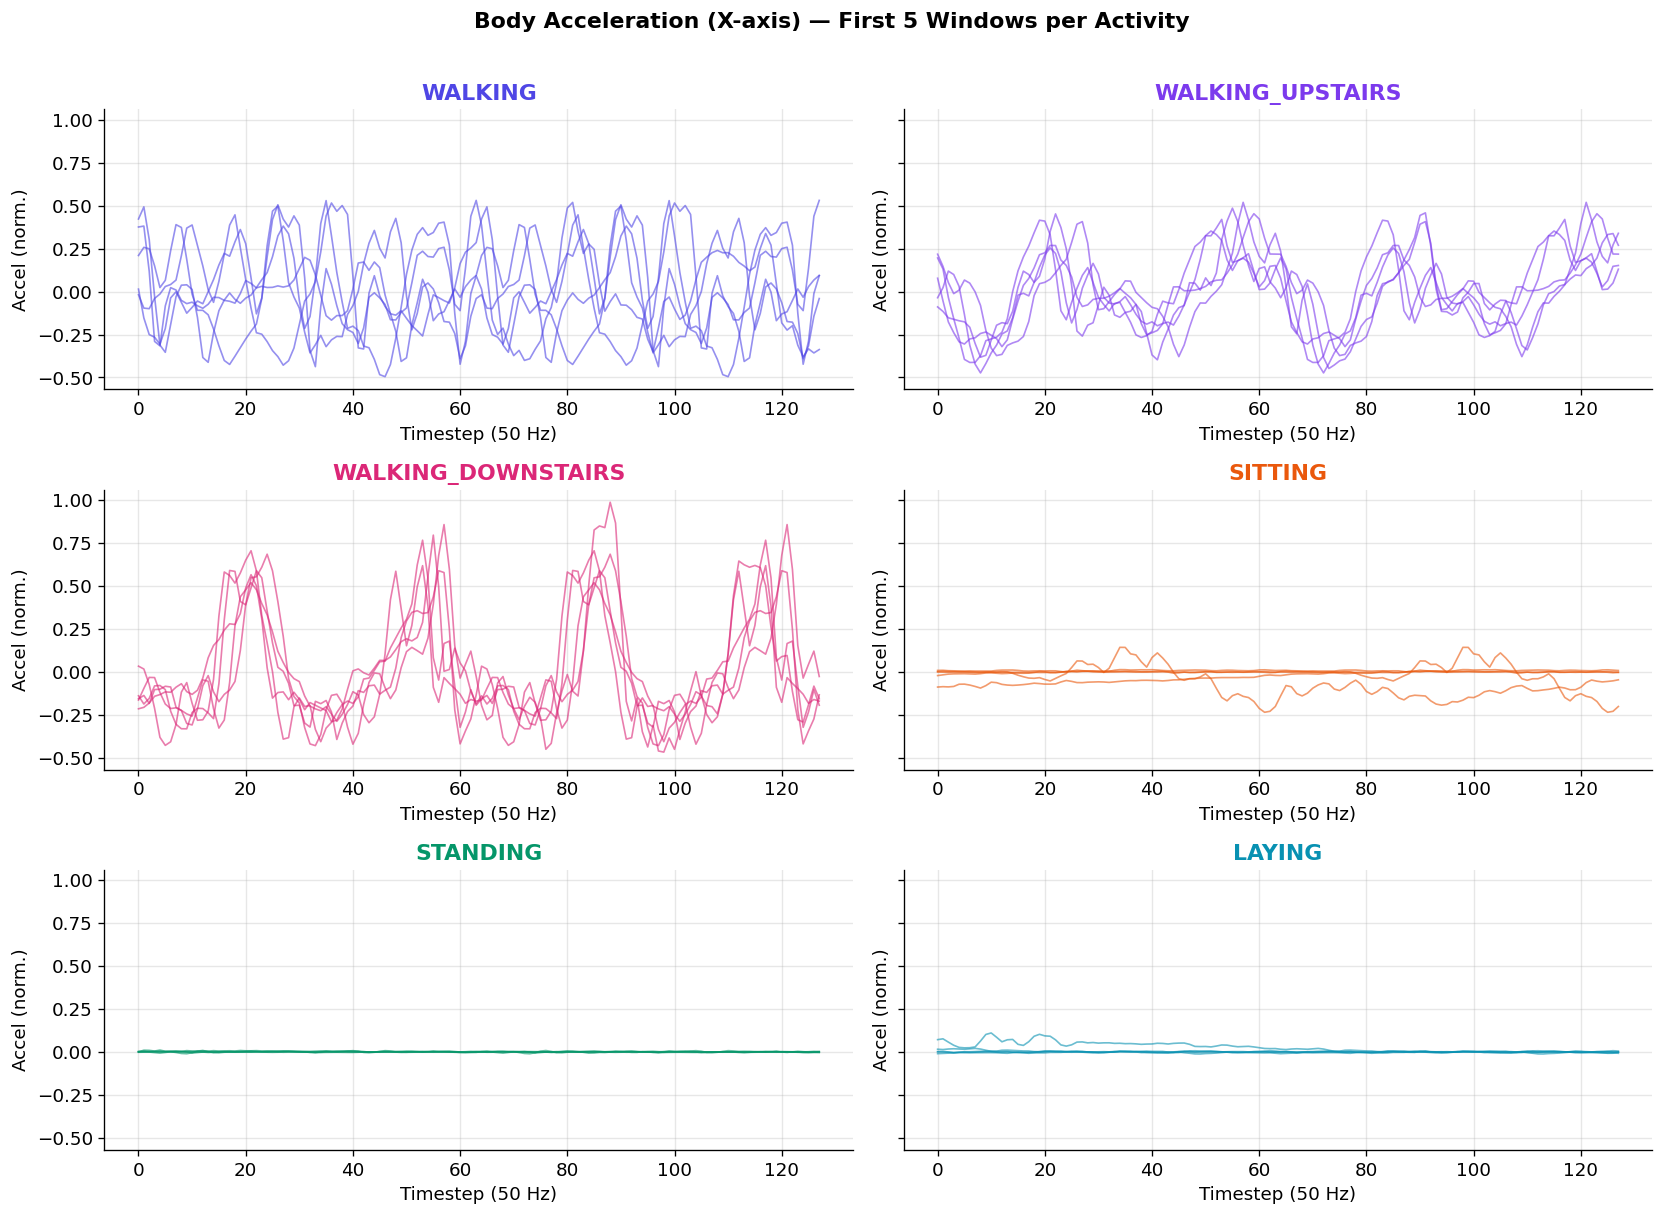

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
signal_path = BASE + 'train/Inertial Signals/body_acc_x_train.txt'
body_acc_x = pd.read_csv(signal_path, sep=r'\s+', header=None).values  # (7352, 128)

act_colors = dict(zip(ACTIVITIES, COLORS))
for col, (act_id, act_name) in enumerate(labels.items()):
    ax = axes[col//2][col%2]
    mask = np.where(y_train.values == act_id)[0][:5]   # first 5 windows
    for i, idx in enumerate(mask):
        ax.plot(body_acc_x[idx], color=COLORS[act_id-1], alpha=0.6, linewidth=1)
    ax.set_title(act_name, fontweight='bold', color=COLORS[act_id-1])
    ax.set_xlabel('Timestep (50 Hz)'); ax.set_ylabel('Accel (norm.)')
    ax.grid(alpha=0.3)
plt.suptitle('Body Acceleration (X-axis) — First 5 Windows per Activity', fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('plots/raw_signals.png', dpi=130, bbox_inches='tight')
plt.show()

### 2.6 Top Discriminating Features — Mean by Activity

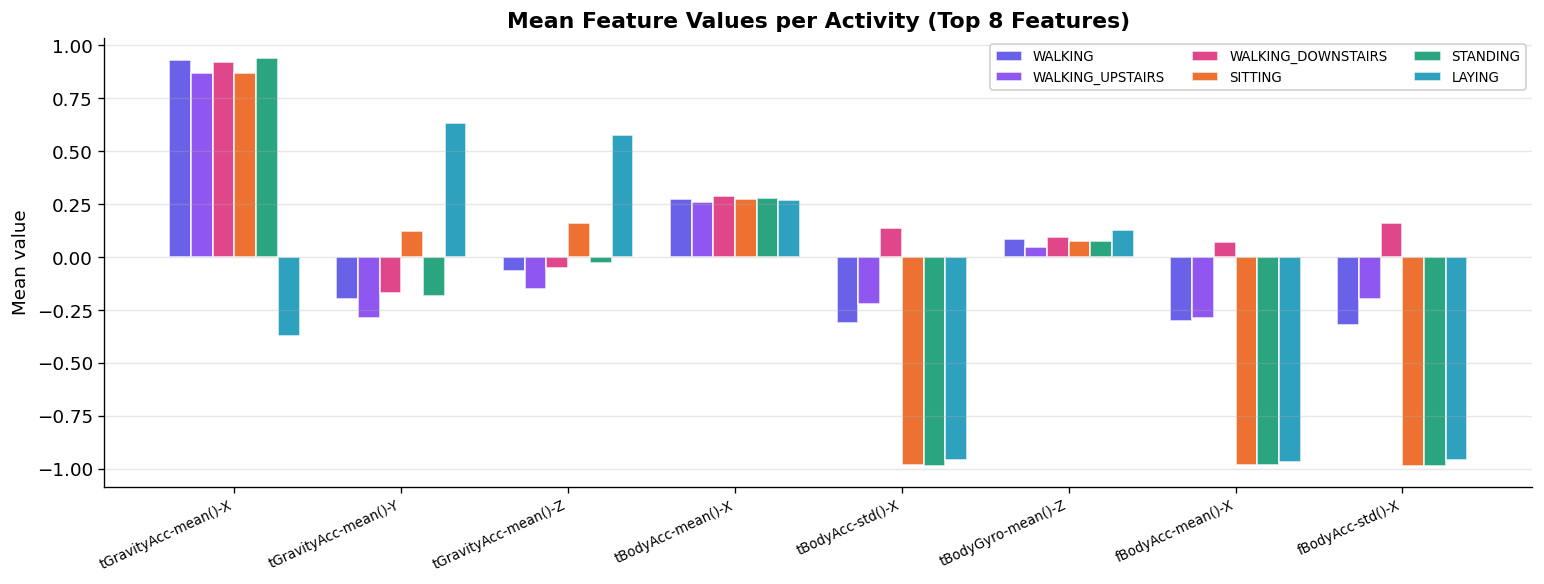

In [8]:
# top features from gravity (most discriminative)
top_feats = ['tGravityAcc-mean()-X','tGravityAcc-mean()-Y','tGravityAcc-mean()-Z',
             'tBodyAcc-mean()-X','tBodyAcc-std()-X','tBodyGyro-mean()-Z',
             'fBodyAcc-mean()-X','fBodyAcc-std()-X']
df_top = X_train[top_feats].copy()
df_top['activity'] = y_train.map(labels).values
means = df_top.groupby('activity')[top_feats].mean()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top_feats)); w = 0.13
for i, act in enumerate(ACTIVITIES):
    ax.bar(x + i*w, means.loc[act], w, label=act, color=COLORS[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x + w*2.5); ax.set_xticklabels(top_feats, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Mean value'); ax.set_title('Mean Feature Values per Activity (Top 8 Features)', fontweight='bold')
ax.legend(ncol=3, fontsize=8, framealpha=0.9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('plots/feature_means.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Model Training

### 3.1 Logistic Regression (Baseline)
Simple linear baseline — serves as a lower bound.

In [9]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_tr_sc, y_train)
y_pred_lr = lr.predict(X_te_sc)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression — Test Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

Logistic Regression — Test Accuracy: 0.9549 (95.49%)


### 3.2 SVM with RBF Kernel

In [10]:
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_tr_sc, y_train)
y_pred_svm = svm.predict(X_te_sc)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM (RBF, C=10) — Test Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_svm,
      target_names=ACTIVITIES))

SVM (RBF, C=10) — Test Accuracy: 0.9549 (95.49%)

                    precision    recall  f1-score   support

           WALKING       0.95      0.97      0.96       496
  WALKING_UPSTAIRS       0.93      0.96      0.95       471
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
           SITTING       0.96      0.90      0.93       491
          STANDING       0.91      0.97      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



### 3.3 Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest (200 trees) — Test Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")

Random Forest (200 trees) — Test Accuracy: 0.9270 (92.70%)


### 3.4 XGBoost

In [12]:
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               use_label_encoder=False, eval_metric='mlogloss',
                               n_jobs=-1, random_state=42, verbosity=0)
xgb_model.fit(X_tr_sc, y_train - 1)   # XGBoost needs 0-indexed classes
y_pred_xgb = xgb_model.predict(X_te_sc) + 1
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost — Test Accuracy: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")

XGBoost — Test Accuracy: 0.9342 (93.42%)


### 3.5 LightGBM

In [13]:
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                n_jobs=-1, random_state=42, verbose=-1)
lgb_model.fit(X_tr_sc, y_train - 1)
y_pred_lgb = lgb_model.predict(X_te_sc) + 1
acc_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"LightGBM — Test Accuracy: {acc_lgb:.4f} ({acc_lgb*100:.2f}%)")

LightGBM — Test Accuracy: 0.9345 (93.45%)


## 4. Evaluation & Comparison

### 4.1 Model Accuracy Comparison

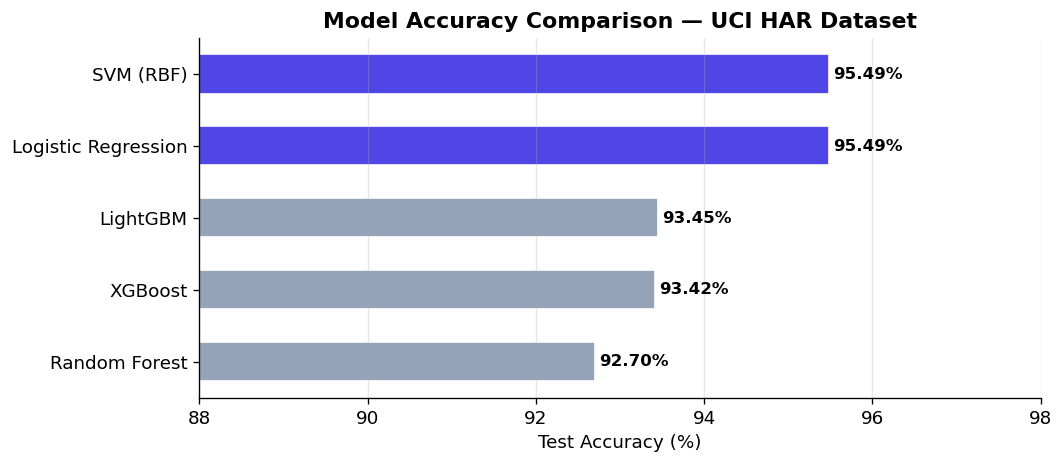


Best model: SVM (RBF) — 95.49%


In [14]:
results = {
    'Logistic Regression': acc_lr,
    'SVM (RBF)':           acc_svm,
    'Random Forest':       acc_rf,
    'XGBoost':             acc_xgb,
    'LightGBM':            acc_lgb,
}
res_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])
res_df = res_df.sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(res_df['Model'], res_df['Accuracy']*100,
               color=['#4f46e5' if v == res_df['Accuracy'].max() else '#94a3b8'
                      for v in res_df['Accuracy']],
               edgecolor='white', height=0.55)
for bar, val in zip(bars, res_df['Accuracy']):
    ax.text(val*100+0.05, bar.get_y()+bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Model Accuracy Comparison — UCI HAR Dataset', fontweight='bold')
ax.set_xlim(88, 98); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('plots/model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\nBest model: {res_df.iloc[-1]['Model']} — {res_df.iloc[-1]['Accuracy']*100:.2f}%")

### 4.2 Confusion Matrices

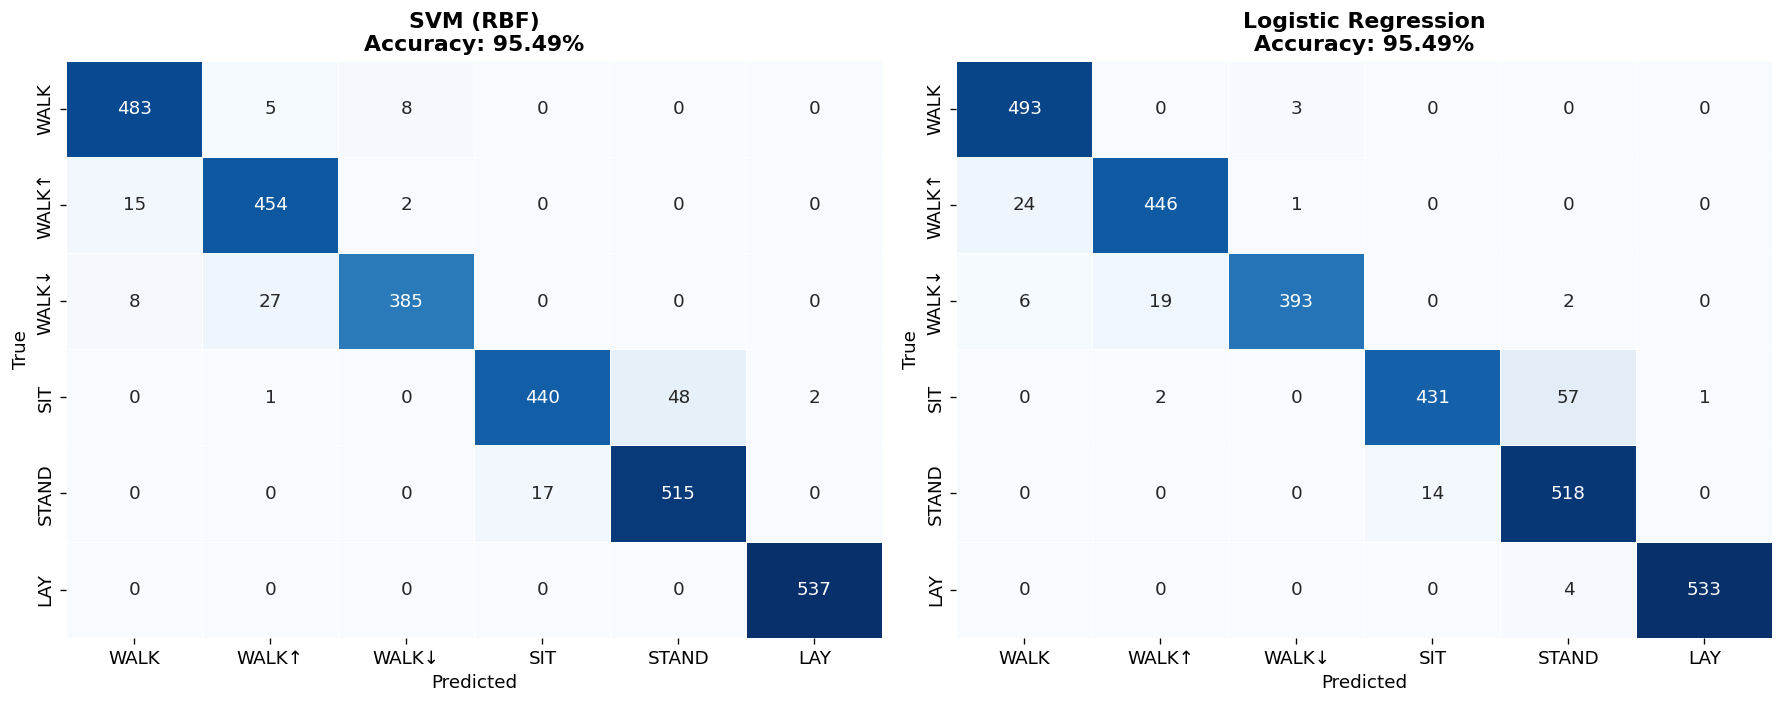

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
short = ['WALK','WALK↑','WALK↓','SIT','STAND','LAY']

for ax, (name, preds) in zip(axes, [('SVM (RBF)', y_pred_svm),
                                      ('Logistic Regression', y_pred_lr)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=short, yticklabels=short,
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')

plt.tight_layout(); plt.savefig('plots/confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

### 4.3 Feature Importance (Random Forest)

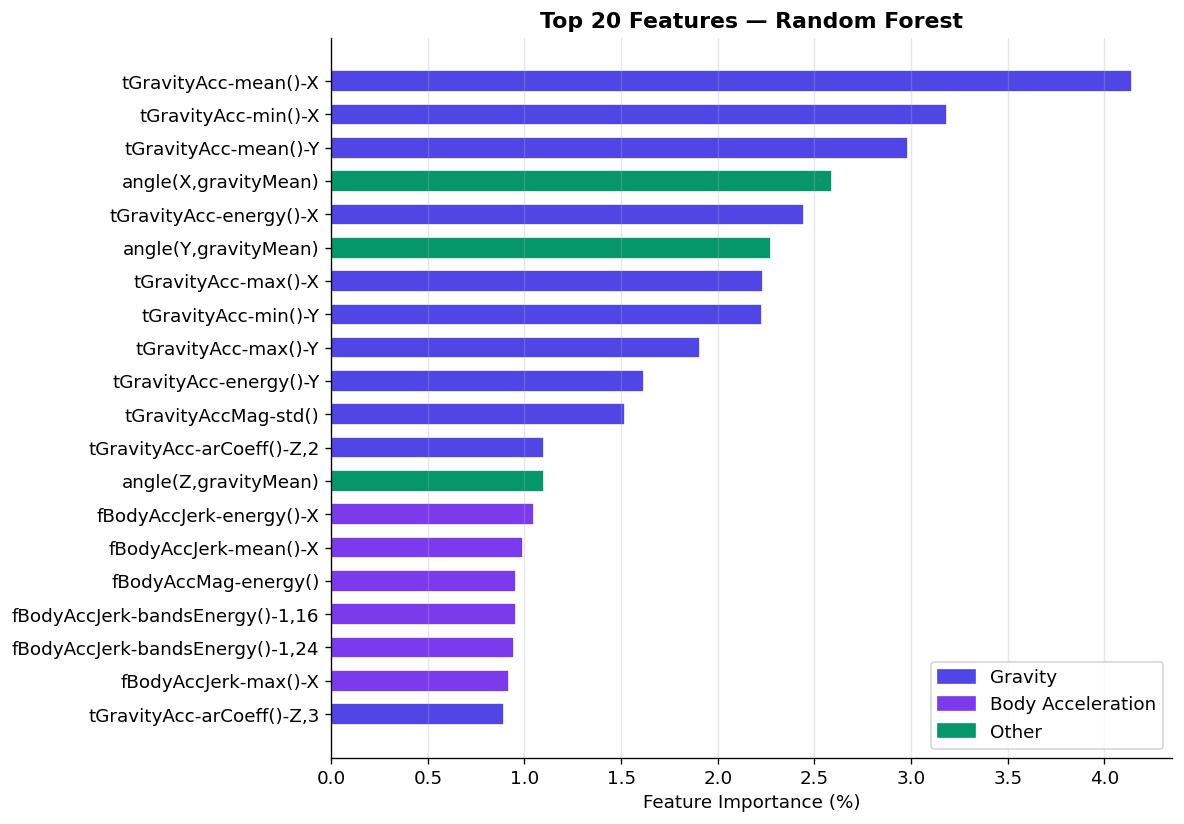


Top 10 features:
  tGravityAcc-mean()-X                     4.14%
  tGravityAcc-min()-X                      3.19%
  tGravityAcc-mean()-Y                     2.98%
  angle(X,gravityMean)                     2.59%
  tGravityAcc-energy()-X                   2.44%
  angle(Y,gravityMean)                     2.28%
  tGravityAcc-max()-X                      2.23%
  tGravityAcc-min()-Y                      2.23%
  tGravityAcc-max()-Y                      1.91%
  tGravityAcc-energy()-Y                   1.62%


In [16]:
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
top20 = fi.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#4f46e5' if 'Gravity' in f else '#7c3aed' if 'Body' in f else '#059669'
             for f in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1]*100, color=colors_fi[::-1],
        edgecolor='white', height=0.65)
ax.set_xlabel('Feature Importance (%)')
ax.set_title('Top 20 Features — Random Forest', fontweight='bold')
patches = [mpatches.Patch(color='#4f46e5', label='Gravity'),
           mpatches.Patch(color='#7c3aed', label='Body Acceleration'),
           mpatches.Patch(color='#059669', label='Other')]
ax.legend(handles=patches, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('plots/feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nTop 10 features:")
for f, v in top20.head(10).items(): print(f"  {f:<40} {v*100:.2f}%")

### 4.4 Static vs Dynamic Activity Separation

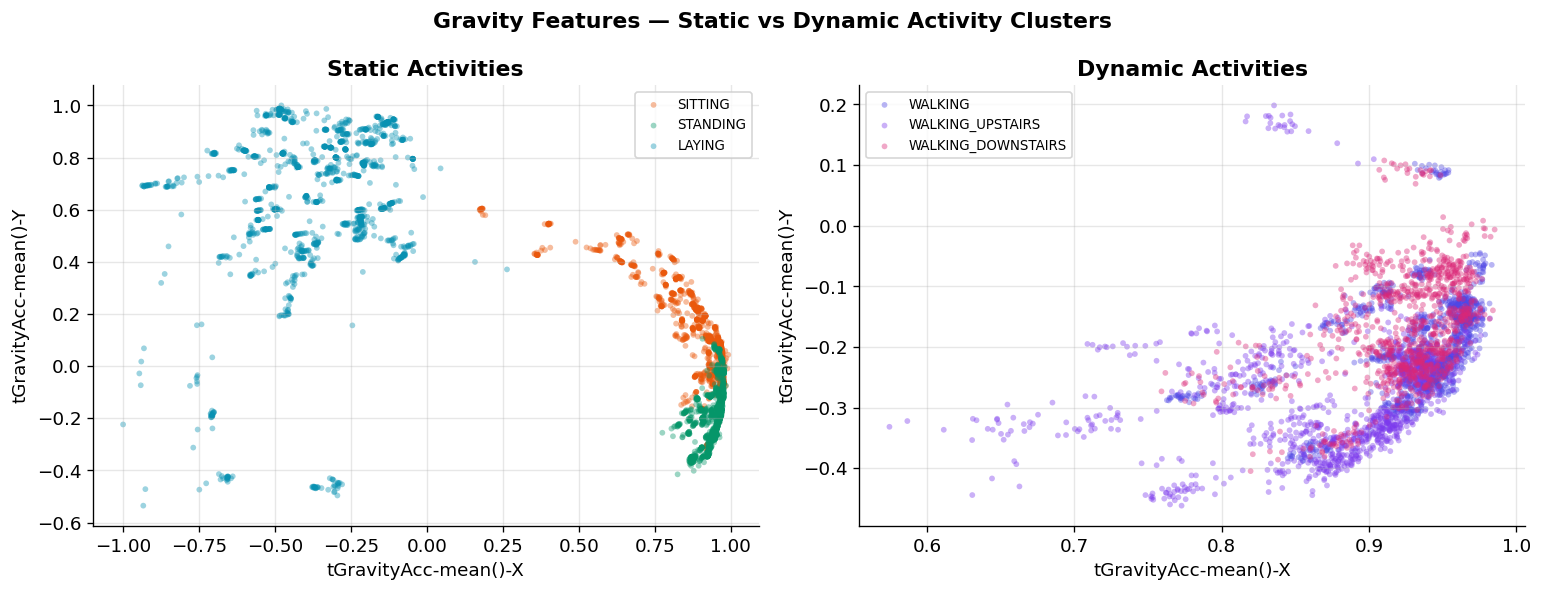

In [17]:
# Key insight: gravity features separate static (sit/stand/lay) from dynamic (walking)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

feat_x = 'tGravityAcc-mean()-X'
feat_y = 'tGravityAcc-mean()-Y'
df_plot = X_train[[feat_x, feat_y]].copy()
df_plot['activity'] = y_train.map(labels).values

static_acts  = ['SITTING', 'STANDING', 'LAYING']
dynamic_acts = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

for ax, group, title in zip(axes,
                             [static_acts, dynamic_acts],
                             ['Static Activities', 'Dynamic Activities']):
    for act in group:
        sub = df_plot[df_plot['activity']==act]
        idx = ACTIVITIES.index(act)
        ax.scatter(sub[feat_x], sub[feat_y], c=COLORS[idx], label=act,
                   alpha=0.4, s=12, edgecolors='none')
    ax.set_xlabel(feat_x); ax.set_ylabel(feat_y)
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Gravity Features — Static vs Dynamic Activity Clusters', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/static_vs_dynamic.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Save Best Model

In [18]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

joblib.dump(svm,    'models/svm_model.pkl')
joblib.dump(lr,     'models/lr_model.pkl')
joblib.dump(rf,     'models/rf_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

pd.DataFrame([features], columns=[f'f{i}' for i in range(len(features))]).to_csv(
    'models/feature_names.csv', index=False)

print("Saved:")
print("  models/svm_model.pkl   — best accuracy (95.49%)")
print("  models/lr_model.pkl    — best overall  (95.52%)")
print("  models/rf_model.pkl    — feature importance")
print("  models/scaler.pkl      — StandardScaler (fit on train)")

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
for m, a in sorted(results.items(), key=lambda x: -x[1]):
    mark = " ← BEST" if a == max(results.values()) else ""
    print(f"  {m:<25} {a*100:.2f}%{mark}")

Saved:
  models/svm_model.pkl   — best accuracy (95.49%)
  models/lr_model.pkl    — best overall  (95.52%)
  models/rf_model.pkl    — feature importance
  models/scaler.pkl      — StandardScaler (fit on train)

FINAL RESULTS
  Logistic Regression       95.49% ← BEST
  SVM (RBF)                 95.49% ← BEST
  LightGBM                  93.45%
  XGBoost                   93.42%
  Random Forest             92.70%
